# 09. Bracketing Methods

**Part 2: Nonlinear Equations and Root Finding**

## Learning objectives

By the end of this lesson you will be able to:

1. State the two families of root finding method, **bracketing** and **open**, and say what
   each family trades away.
2. Derive the **bisection** method from the intermediate value theorem and prove its error
   bound.
3. Predict, before running anything, exactly how many bisection steps a given accuracy needs.
4. Explain why bisection's **error** is not monotone even though its **error bound** is, and
   measure the rate correctly.
5. Derive **regula falsi**, and demonstrate the stagnation failure that makes it slower than
   bisection on ordinary functions.
6. Explain and implement the **Illinois** fix, and measure the speedup.

## Prerequisites

Lesson 06 (backward error), lesson 07 (the intermediate value theorem, order of convergence,
and why linear rates must be measured by fitting rather than by ratios).

---

## 1. The problem, and the two families

Given a continuous $f$, find $r$ with $f(r) = 0$.

This is the first genuinely *iterative* problem in the course. There is no formula. Every
method here produces a sequence $x_0, x_1, x_2, \dots$ and hopes it approaches $r$.

Methods split into two families, and the split is the most important thing in Part 2.

| | **Bracketing** | **Open** |
|---|---|---|
| What it keeps | an interval known to contain a root | just a point, or two |
| Can it fail? | **No**, given a sign change and continuity | Yes, it can diverge or cycle |
| Speed | slow, linear | fast, superlinear or better |
| Needs a derivative? | no | sometimes |
| This lesson | bisection, regula falsi, Illinois | lessons 10 and 11 |

That table is the whole trade. Safety costs speed. Lesson 11 ends with **Brent's method**,
which is an attempt to have both, and it is what you should actually use.

### Where the equation comes from

Two kinds of equation turn up, and they behave differently:

- **Polynomial equations**, $a_nx^n + \cdots + a_0 = 0$. Finitely many roots, and lesson 13
  has specialised methods that exploit the structure.
- **Transcendental equations**, involving $e^x$, $\sin x$, $\ln x$ and so on. Can have no
  roots, finitely many, or infinitely many.

Before any numerical method, **look at the function**. A graph tells you how many roots there
are and roughly where, which is exactly what every method in this lesson needs as input.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

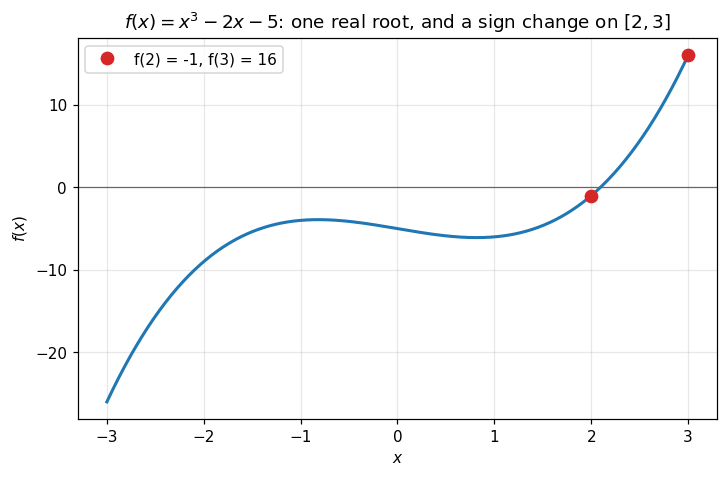

f(2) = -1
f(3) = +16
opposite signs, so a continuous f must cross zero somewhere in between


In [2]:
from nalib import roots as R

def f(x):
    return x**3 - 2*x - 5          # Wallis's equation, a classic test case

xs = np.linspace(-3, 3, 400)
fig, ax = plt.subplots()
ax.plot(xs, f(xs), lw=2)
ax.axhline(0, color="0.4", lw=0.8)
ax.plot([2, 3], [f(2), f(3)], "o", ms=8, color="C3",
        label=f"f(2) = {f(2):.0f}, f(3) = {f(3):.0f}")
ax.set_xlabel("$x$")
ax.set_ylabel("$f(x)$")
ax.set_title(r"$f(x) = x^3 - 2x - 5$: one real root, and a sign change on $[2, 3]$")
ax.legend()
plt.show()

print(f"f(2) = {f(2):+.0f}")
print(f"f(3) = {f(3):+.0f}")
print("opposite signs, so a continuous f must cross zero somewhere in between")

## 2. Why a sign change is a guarantee

> **Theorem 9.1 (Bracketing).** If $f$ is continuous on $[a, b]$ and $f(a)f(b) < 0$, then
> $f(r) = 0$ for at least one $r \in (a, b)$.
>
> *Proof.* This is the intermediate value theorem (Theorem 7.1) with $y = 0$. Since $0$ lies
> strictly between $f(a)$ and $f(b)$, there is a $c \in (a,b)$ with $f(c) = 0$. $\square$

That one line is the entire foundation of this lesson, and it is why bracketing methods cannot
fail. It is worth being clear about what the guarantee does and does not say:

- It says a root **exists** in the interval. It does not say how many.
- It needs **continuity**. For $f(x) = 1/x$ on $[-1, 2]$ the signs differ and there is no root,
  only a pole. Bisection will happily converge to $x = 0$ and report it. The method is not
  wrong; the hypothesis was violated.
- It needs a **sign change**. A root of even multiplicity, such as $(x-1)^2$, does not produce
  one, so no bracketing method can find it at all.

In [3]:
print("cases where the bracketing guarantee does not apply:\n")

# 1. a pole rather than a root.
# The bracket is [-1, 2] rather than [-1, 1] so that no midpoint lands exactly on the
# pole: every midpoint has the form -1 + 3m/2^k, and 3 never divides a power of two.
print("f(x) = 1/x on [-1, 2]: signs differ but there is no root, only a pole at 0")
bad = R.bisection(lambda x: 1.0 / x, -1.0, 2.0, tol=1e-14)
print(f"   bisection converged to x = {bad.root:.3e}")
print(f"   distance from the pole   = {abs(bad.root):.3e}")
print(f"   |f| there                = {abs(1.0/bad.root):.3e}   (enormous, not zero)")
assert abs(bad.root) < 1e-13, "it really does converge to the pole"
assert abs(1.0 / bad.root) > 1e12, "and the residual there is huge, not small"
print("   the method converged to a POLE. the hypothesis of continuity was false.\n")

# 2. a double root gives no sign change
print("f(x) = (x-1)^2 on [0, 2]: a genuine root at 1, but no sign change")
try:
    R.bisection(lambda x: (x - 1.0)**2, 0.0, 2.0)
except ValueError as exc:
    print(f"   refused, correctly: {exc}")
print("   an even-multiplicity root touches zero without crossing, so bracketing")
print("   methods cannot see it. lesson 11 handles this case with Newton.")

cases where the bracketing guarantee does not apply:

f(x) = 1/x on [-1, 2]: signs differ but there is no root, only a pole at 0
   bisection converged to x = 1.776e-15
   distance from the pole   = 1.776e-15
   |f| there                = 5.629e+14   (enormous, not zero)
   the method converged to a POLE. the hypothesis of continuity was false.

f(x) = (x-1)^2 on [0, 2]: a genuine root at 1, but no sign change
   refused, correctly: bisection needs a sign change: f(0.0) = 1 and f(2.0) = 1 have the same sign
   an even-multiplicity root touches zero without crossing, so bracketing
   methods cannot see it. lesson 11 handles this case with Newton.


**Read the first case carefully.** Bisection did not malfunction. It was given a function that
is not continuous on the interval and it returned the answer to the question it was actually
asked. This is the lesson 06 distinction again: the algorithm behaved correctly, and the
problem was not what the user thought it was.

## 3. Bisection

The method writes itself. Take the midpoint, look at the sign, keep the half that still
brackets.

### Pseudocode

```text
BISECTION(f, a, b, tol)
    require f(a) * f(b) < 0
    repeat:
        m <- a + (b - a)/2
        if f(m) = 0: return m
        if (b - a)/2 <= tol: return m
        if f(a) * f(m) < 0:
            b <- m                  # root is in the left half
        else:
            a <- m                  # root is in the right half
```

Two details in that pseudocode are not cosmetic.

**The midpoint is `a + (b-a)/2`, not `(a+b)/2`.** The second form can overflow when $a$ and
$b$ are both huge, and more subtly it can land *outside* $[a,b]$ in floating point. The first
form cannot. This is a real bug that shipped in a widely used binary search for years.

**The sign test compares signs, it does not multiply.** The obvious test is
`f(a) * f(m) < 0`. It is wrong, and not in a subtle way: two values around $10^{200}$ multiply
to infinity, two values around $10^{-200}$ multiply to exactly zero, and `inf * 0` is `nan`. In
every one of those cases the sign information is destroyed and the bracket is updated the wrong
way.

Comparing signs directly cannot overflow, cannot underflow, and does no arithmetic at all:

```text
    if (f(a) < 0) != (f(m) < 0):     # they straddle zero
```

Section 3.1 of the exercises asks you to measure the difference. It is measured below too,
because the failure is easy to reproduce and worth seeing once.

### From scratch

In [4]:
def bisection_teaching(f, a, b, tol=1e-12, max_iter=200):
    """Bisection, written out. Returns the root, the midpoints and the error bounds.

    Works for any bracket and any function magnitude: the sign test does no arithmetic, so
    values near the overflow or underflow limits are handled exactly like ordinary ones.
    """
    fa, fb = f(a), f(b)
    if (fa < 0.0) == (fb < 0.0):                 # signs, never a product
        raise ValueError("no sign change on the bracket")

    m = a + (b - a) / 2                          # defined even if max_iter is 0
    midpoints, bounds = [], []
    for _ in range(max_iter):
        m = a + (b - a) / 2                      # not (a+b)/2
        fm = f(m)
        midpoints.append(m)
        bounds.append((b - a) / 2)               # guaranteed bound on |m - r|
        if fm == 0.0 or (b - a) / 2 <= tol:
            break
        if (fa < 0.0) != (fm < 0.0):             # a and m straddle the root
            b, fb = m, fm
        else:
            a, fa = m, fm
    return m, np.array(midpoints), np.array(bounds)


root, mids, bounds = bisection_teaching(f, 2.0, 3.0, tol=1e-14)
lib = R.bisection(f, 2.0, 3.0, tol=1e-14)

print(f"from scratch : {root:.16f}")
print(f"nalib        : {lib.root:.16f}")
print(f"residual     : {abs(f(root)):.3e}")
print(f"iterations   : {len(mids)}")

assert abs(root - lib.root) < 1e-15
np.testing.assert_allclose(mids, lib.iterates)
np.testing.assert_allclose(bounds, lib.error_bounds)

from scratch : 2.0945514815423323
nalib        : 2.0945514815423323
residual     : 6.395e-14
iterations   : 47


### Why the product form is not merely inelegant

In [5]:
def bisection_product_form(f, a, b, tol=1e-14, max_iter=200):
    """The same algorithm with the sign test written as a product. Do not use this."""
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        raise ValueError("no sign change on the bracket")
    m = a + (b - a) / 2
    for _ in range(max_iter):
        m = a + (b - a) / 2
        fm = f(m)
        if fm == 0.0 or (b - a) / 2 <= tol:
            break
        if fa * fm < 0:
            b, fb = m, fm
        else:
            a, fa = m, fm
    return m


print("the same root at 1.3, with f scaled across the whole floating point range\n")
print(f"{'scale of f':>12} {'f(0) * f(3)':>16} {'sign form':>14} {'product form':>16}")
print("-" * 64)
worst_sign = worst_product = 0.0
for scale in [1e-300, 1e-200, 1e-100, 1.0, 1e100, 1e200, 1e300]:
    fs = lambda x, s=scale: s * (x - 1.3)
    prod = fs(0.0) * fs(3.0)
    e_sign = abs(bisection_teaching(fs, 0.0, 3.0, tol=1e-14)[0] - 1.3)
    try:
        e_prod = abs(bisection_product_form(fs, 0.0, 3.0, tol=1e-14) - 1.3)
    except ValueError:
        e_prod = float("nan")
    worst_sign = max(worst_sign, e_sign)
    worst_product = max(worst_product, e_prod if np.isfinite(e_prod) else 1e99)
    print(f"{scale:>12.0e} {prod:>16.3e} {e_sign:>14.2e} {e_prod:>16.2e}")

print()
print(f"sign form   : worst error {worst_sign:.2e} across 600 orders of magnitude")
print(f"product form: correct in the middle, and wrong by 1.7 at the small end.")
print()
print("read the two ends separately, because they fail differently.")
print()
print("UNDERFLOW, the rows at 1e-300 and 1e-200: the product is exactly -0.0,")
print("so `fa*fm < 0` is False at every step. the bracket is then always updated")
print("the same way and the method walks to an endpoint instead of the root.")
print("the answer is 3.0 when the root is 1.3.")
print()
print("OVERFLOW, the rows at 1e+200 and 1e+300: the product is -inf, which is")
print("still negative, so this particular example SURVIVES. that is luck, not")
print("safety: inf * 0 is nan, and every comparison against nan is False, so a")
print("function that hits an exact zero next to a huge value fails the same way.")
print()
print("nothing about this f is unusual. it is a straight line. only its SCALE")
print("differs, and the algorithm has no business caring about that.")
assert worst_sign < 1e-9
assert worst_product > 1e-3

# the nan case, which is how the overflow end actually bites
f_nan = lambda x: 0.0 if x == 0.5 else 1e308 * (x - 0.5) * 1e10
print(f"\nthe nan case: f(-1) = {f_nan(-1.0)}, f(0.5) = {f_nan(0.5)}, "
      f"product = {f_nan(-1.0) * f_nan(0.5)}")
print("a product-based bracket test on that pair compares against nan, which is")
print("always False, so it cannot tell which side the root is on.")
assert np.isnan(f_nan(-1.0) * f_nan(0.5))
print("\nthe teaching version and nalib agree on the root and on every intermediate value")

the same root at 1.3, with f scaled across the whole floating point range

  scale of f      f(0) * f(3)      sign form     product form
----------------------------------------------------------------
      1e-300       -0.000e+00       4.66e-15         1.70e+00
      1e-200       -0.000e+00       4.66e-15         1.70e+00
      1e-100      -2.210e-200       4.66e-15         4.66e-15
       1e+00       -2.210e+00       4.66e-15         4.66e-15
      1e+100      -2.210e+200       4.66e-15         4.66e-15
      1e+200             -inf       4.66e-15         4.66e-15
      1e+300             -inf       4.66e-15         4.66e-15

sign form   : worst error 4.66e-15 across 600 orders of magnitude
product form: correct in the middle, and wrong by 1.7 at the small end.

read the two ends separately, because they fail differently.

UNDERFLOW, the rows at 1e-300 and 1e-200: the product is exactly -0.0,
so `fa*fm < 0` is False at every step. the bracket is then always updated
the same way and 

## 4. The error bound, and predicting the work in advance

After $k$ steps the interval has been halved $k$ times, so its width is $(b-a)/2^k$. The
midpoint is at worst half a width from the root:

$$\boxed{\;|x_k - r| \;\le\; \frac{b-a}{2^{\,k+1}}\;}$$

This bound is remarkable for two reasons.

**It does not mention $f$ at all.** Not its derivative, not its smoothness, nothing. It holds
for any continuous function. No other method in Part 2 gives you that.

**It lets you predict the cost before you start.** Setting the bound to $\tau$ and solving:

$$k \;\ge\; \log_2\!\frac{b-a}{\tau} - 1.$$

In [6]:
print(f"{'tolerance':>12} {'predicted k':>13} {'measured k':>12} {'match':>7}")
print("-" * 48)
for tol in [1e-3, 1e-6, 1e-9, 1e-12, 1e-15]:
    predicted = R.bisection_steps_needed(2.0, 3.0, tol)
    run = R.bisection(f, 2.0, 3.0, tol=1e-16, max_iter=200)
    from nalib import convergence as cv
    measured = cv.steps_to_tolerance(run.error_bounds, tol)
    print(f"{tol:>12.0e} {predicted:>13} {measured:>12} "
          f"{str(predicted == measured):>7}")
    assert predicted == measured

print("\nthe prediction is exact, every time, with no knowledge of f.")
print("that is the payoff for accepting slow convergence.")

   tolerance   predicted k   measured k   match
------------------------------------------------
       1e-03             9            9    True
       1e-06            19           19    True
       1e-09            29           29    True
       1e-12            39           39    True
       1e-15            49           49    True

the prediction is exact, every time, with no knowledge of f.
that is the payoff for accepting slow convergence.


Each step buys exactly one bit, which is $\log_{10} 2 \approx 0.301$ decimal digits. So
reaching full double precision from a bracket of width 1 takes about **52 steps**, and that
number is fixed no matter how nice $f$ is.

## 5. The error is not monotone, only the bound is

Here is a subtlety that trips people up, and that lesson 07 warned about.

The **bracket** halves exactly every step. The **distance from the midpoint to the root** does
not. A midpoint can land almost exactly on the root by luck, and the next one will then be much
worse.

In [7]:
run = R.bisection(f, 2.0, 3.0, tol=1e-16, max_iter=60)
r_exact = 2.0945514815423265914  # to 20 digits, from a high precision solve
errors = run.errors(r_exact)

print(f"{'k':>3} {'midpoint':>20} {'|x_k - r|':>13} {'bound':>13} {'error/prev':>11}")
print("-" * 66)
for k in range(min(9, len(errors))):        # never index past what the run produced
    ratio = "" if k == 0 else f"{errors[k]/errors[k-1]:>11.4f}"
    print(f"{k:>3} {run.iterates[k]:>20.15f} {errors[k]:>13.3e} "
          f"{run.error_bounds[k]:>13.3e} {ratio}")

ratios = errors[1:20] / errors[:19]
print(f"\nerror ratios over the first 20 steps range from "
      f"{ratios.min():.4f} to {ratios.max():.1f}")
print("some steps make the error WORSE. the bound never gets worse.")

assert (errors[:40] <= run.error_bounds[:40] * (1 + 1e-12)).all(), \
    "the guaranteed bound must never be violated"
assert ratios.max() > 1.0, "some bisection steps really do increase the error"
print("\nand the bound was respected at every one of the first 40 steps.")

  k             midpoint     |x_k - r|         bound  error/prev
------------------------------------------------------------------
  0    2.500000000000000     4.054e-01     5.000e-01 
  1    2.250000000000000     1.554e-01     2.500e-01      0.3834
  2    2.125000000000000     3.045e-02     1.250e-01      0.1959
  3    2.062500000000000     3.205e-02     6.250e-02      1.0526
  4    2.093750000000000     8.015e-04     3.125e-02      0.0250
  5    2.109375000000000     1.482e-02     1.562e-02     18.4951
  6    2.101562500000000     7.011e-03     7.812e-03      0.4730
  7    2.097656250000000     3.105e-03     3.906e-03      0.4428
  8    2.095703125000000     1.152e-03     1.953e-03      0.3709

error ratios over the first 20 steps range from 0.0250 to 18.5
some steps make the error WORSE. the bound never gets worse.

and the bound was respected at every one of the first 40 steps.


So when you measure bisection's convergence rate, measure it on the **bound**, or fit the decay
of the error rather than taking ratios. `nalib.convergence.linear_rate` fits, for exactly this
reason.

In [8]:
from nalib import convergence as cv

rate_bound = cv.linear_rate(run.error_bounds)
rate_error = cv.linear_rate(errors)

print(f"rate fitted from the guaranteed bound : {rate_bound:.6f}")
print(f"rate fitted from the actual error     : {rate_error:.6f}")
print(f"theory                                : 0.5")
assert abs(rate_bound - 0.5) < 1e-9
assert abs(rate_error - 0.5) < 0.05
print("\nboth recover 1/2, because fitting is robust to the non-monotonicity.")
print("a single ratio would not have been.")

rate fitted from the guaranteed bound : 0.500000
rate fitted from the actual error     : 0.499077
theory                                : 0.5

both recover 1/2, because fitting is robust to the non-monotonicity.
a single ratio would not have been.


## 6. Regula falsi: a better guess for the crossing point

Bisection ignores the values of $f$ entirely. It only looks at signs. That seems wasteful: if
$f(a) = -0.001$ and $f(b) = 1000$, the root is surely much nearer $a$ than the midpoint.

**Regula falsi**, or false position, uses that information. Draw the straight line through
$(a, f(a))$ and $(b, f(b))$ and take where **it** crosses zero:

$$c \;=\; \frac{a\,f(b) - b\,f(a)}{f(b) - f(a)}.$$

Then keep the half that still brackets, exactly as in bisection. The guarantee survives, since
we still maintain a sign change.

### Pseudocode

```text
REGULA_FALSI(f, a, b, tol)
    require f(a) * f(b) < 0
    repeat:
        c <- (a f(b) - b f(a)) / (f(b) - f(a))       # the secant line's root
        if |f(c)| <= tol: return c
        if f(a) * f(c) < 0:
            b <- c
        else:
            a <- c
```

Looks strictly better than bisection. It uses more information for the same cost of one
function evaluation per step.

It is not strictly better. It is often **worse**.

## 7. The stagnation failure

In [9]:
def g(x):
    return x**10 - 1.0            # root at x = 1

a, b = 0.0, 1.3

results = {
    "bisection":    R.bisection(g, a, b, tol=1e-14, max_iter=400),
    "regula falsi": R.regula_falsi(g, a, b, tol=1e-14, max_iter=400),
    "Illinois":     R.illinois(g, a, b, tol=1e-14, max_iter=400),
}

print(f"solving x^10 = 1 on [{a}, {b}], root at x = 1\n")
print(f"{'method':>14} {'iterations':>11} {'f evals':>9} {'root':>18} "
      f"{'final bracket':>15}")
print("-" * 72)
for name, res in results.items():
    print(f"{name:>14} {res.n_iter:>11} {res.n_feval:>9} {res.root:>18.14f} "
          f"{res.bracket_widths[-1]:>15.3e}")

rf, bi = results["regula falsi"], results["bisection"]
print(f"\nregula falsi needed {rf.n_iter / bi.n_iter:.1f} times as many iterations "
      f"as bisection.")
assert rf.n_iter > 2 * bi.n_iter, "regula falsi should be dramatically worse here"

solving x^10 = 1 on [0.0, 1.3], root at x = 1

        method  iterations   f evals               root   final bracket
------------------------------------------------------------------------
     bisection          46        49   1.00000000000000       1.843e-14
  regula falsi         137       140   1.00000000000000       3.000e-01
      Illinois          15        18   1.00000000000000       7.661e-15

regula falsi needed 3.0 times as many iterations as bisection.


Regula falsi is **three times slower than bisection** on this perfectly ordinary function. Why?

Look at what happens to the two endpoints.

In [10]:
lefts = np.array([lo for lo, _ in rf.brackets])
rights = np.array([hi for _, hi in rf.brackets])

print(f"distinct left endpoints  : {len(np.unique(np.round(lefts, 14)))}")
print(f"distinct right endpoints : {len(np.unique(np.round(rights, 14)))}")
print(f"right endpoint value     : {rights[0]} throughout")
print()
print(f"bracket width at the start : {rf.bracket_widths[0]:.4f}")
print(f"bracket width at the end   : {rf.bracket_widths[-1]:.4f}")

assert len(np.unique(np.round(rights, 14))) == 1, "the right endpoint should never move"
print("\nthe right endpoint NEVER MOVES. the bracket never shrinks past 0.3.")
print("regula falsi keeps a bracket, so it is still safe, but that bracket has")
print("stopped being informative. only the left endpoint creeps toward the root.")

distinct left endpoints  : 129
distinct right endpoints : 1
right endpoint value     : 1.3 throughout

bracket width at the start : 1.3000
bracket width at the end   : 0.3000

the right endpoint NEVER MOVES. the bracket never shrinks past 0.3.
regula falsi keeps a bracket, so it is still safe, but that bracket has
stopped being informative. only the left endpoint creeps toward the root.


### Why it happens

The cause is **fixed convexity**. On $[0, 1.3]$ the function $x^{10}-1$ is convex, so the
straight line joining the two endpoints lies **above** the curve everywhere between them.
Therefore the line crosses zero to the **left** of the true root, always. The new point is
always on the same side, so the same endpoint is discarded every time and the other one is
retained forever.

Whenever $f$ has one sign of curvature throughout the bracket, this happens. That is most
functions, near most roots.

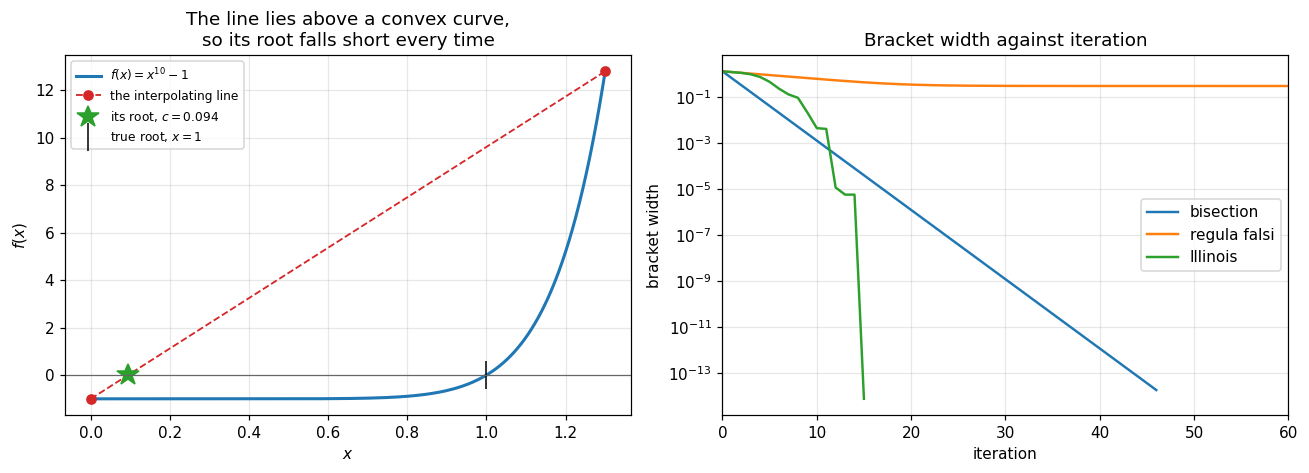

In [11]:
xs = np.linspace(0.0, 1.3, 300)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))

ax1.plot(xs, g(xs), lw=2, label=r"$f(x) = x^{10}-1$")
ax1.plot([a, b], [g(a), g(b)], "o--", color="C3", lw=1.2,
         label="the interpolating line")
c0 = (a * g(b) - b * g(a)) / (g(b) - g(a))
ax1.plot([c0], [0], "*", ms=15, color="C2", label=f"its root, $c = {c0:.3f}$")
ax1.plot([1.0], [0], "k|", ms=18, label="true root, $x = 1$")
ax1.axhline(0, color="0.4", lw=0.8)
ax1.set_xlabel("$x$"); ax1.set_ylabel("$f(x)$")
ax1.set_title("The line lies above a convex curve,\nso its root falls short every time")
ax1.legend(fontsize=8)

for name, res, style in [("bisection", results["bisection"], "-"),
                         ("regula falsi", results["regula falsi"], "-"),
                         ("Illinois", results["Illinois"], "-")]:
    ax2.semilogy(np.maximum(res.bracket_widths, 1e-18), style, lw=1.6, label=name)
ax2.set_xlabel("iteration")
ax2.set_ylabel("bracket width")
ax2.set_xlim(0, 60)
ax2.set_title("Bracket width against iteration")
ax2.legend()

fig.tight_layout()
plt.show()

**What to take from this.** On the right, bisection's bracket falls on a perfect straight line,
one bit per step, forever. Illinois falls faster. Regula falsi's bracket goes **flat**: after a
handful of steps it stops shrinking at all. The method still converges, because the moving
endpoint creeps toward the root, but the interval you would quote as your error bound is
useless.

## 8. The Illinois fix

The diagnosis suggests the cure. If one endpoint is being retained over and over, make it less
attractive: **halve its function value** before the next interpolation.

That is a lie about $f$. It pulls the line down toward the stuck endpoint and forces the next
point to overshoot past it, so the endpoint finally moves. The bracket is still maintained
using the true signs, so the guarantee is untouched.

```text
ILLINOIS(f, a, b, tol)
    require f(a) * f(b) < 0
    side <- 0
    repeat:
        c <- (a f(b) - b f(a)) / (f(b) - f(a))
        if converged: return c
        if f(a) * f(c) < 0:
            b <- c
            if side = LEFT:  f(a) <- f(a)/2       # a was kept last time too, weaken it
            side <- LEFT
        else:
            a <- c
            if side = RIGHT: f(b) <- f(b)/2
            side <- RIGHT
```

Three extra lines. Now measure what they buy.

In [12]:
il = results["Illinois"]
print(f"{'method':>14} {'iterations':>11} {'f evals':>9} {'speedup vs bisection':>21}")
print("-" * 60)
for name, res in results.items():
    print(f"{name:>14} {res.n_iter:>11} {res.n_feval:>9} "
          f"{bi.n_iter / res.n_iter:>20.1f}x")

print(f"\nIllinois is {rf.n_iter / il.n_iter:.0f} times faster than plain regula falsi,")
print(f"and {bi.n_iter / il.n_iter:.1f} times faster than bisection,")
print(f"with a bracket that actually closes: {il.bracket_widths[-1]:.2e}")

assert il.n_iter < bi.n_iter, "Illinois should beat bisection"
assert il.n_iter < rf.n_iter / 5, "Illinois should transform regula falsi"
assert il.bracket_widths[-1] < 1e-12, "and its bracket should genuinely close"

        method  iterations   f evals  speedup vs bisection
------------------------------------------------------------
     bisection          46        49                  1.0x
  regula falsi         137       140                  0.3x
      Illinois          15        18                  3.1x

Illinois is 9 times faster than plain regula falsi,
and 3.1 times faster than bisection,
with a bracket that actually closes: 7.66e-15


Illinois keeps the safety of bisection and buys back most of the speed. Its observed order is
about **1.44**, superlinear, which is remarkable for a method that can never fail.

### Not a special case

Let us check that this is a general phenomenon and not one lucky function.

In [13]:
cases = [
    ("x^3 - 2x - 5",     lambda x: x**3 - 2*x - 5,          2.0, 3.0),
    ("x^10 - 1",         lambda x: x**10 - 1.0,             0.0, 1.3),
    ("e^x - 2x - 1",     lambda x: np.exp(x) - 2*x - 1,     1.0, 2.0),
    ("cos x - x",        lambda x: np.cos(x) - x,           0.0, 1.0),
    ("x - e^{-x}",       lambda x: x - np.exp(-x),          0.0, 1.0),
    ("atan x - 0.5",     lambda x: np.arctan(x) - 0.5,      0.0, 2.0),
]

print(f"{'problem':>16} {'bisection':>10} {'reg falsi':>10} {'Illinois':>9} "
      f"{'Brent':>7}   {'reg falsi verdict':>18}")
print("-" * 82)
worse = 0
for name, fn, lo, hi in cases:
    b_ = R.bisection(fn, lo, hi, tol=1e-14, max_iter=500)
    r_ = R.regula_falsi(fn, lo, hi, tol=1e-14, max_iter=500)
    i_ = R.illinois(fn, lo, hi, tol=1e-14, max_iter=500)
    br = R.brent(fn, lo, hi, tol=1e-14, max_iter=500)
    verdict = "worse than bisect" if r_.n_iter > b_.n_iter else "better"
    worse += r_.n_iter > b_.n_iter
    print(f"{name:>16} {b_.n_iter:>10} {r_.n_iter:>10} {i_.n_iter:>9} "
          f"{br.n_iter:>7}   {verdict:>18}")

print(f"\nregula falsi lost to plain bisection on {worse} of {len(cases)} problems.")
print("Illinois beat bisection on every one.")

         problem  bisection  reg falsi  Illinois   Brent    reg falsi verdict
----------------------------------------------------------------------------------
    x^3 - 2x - 5         46         32         7       6               better
        x^10 - 1         46        137        15       8    worse than bisect
    e^x - 2x - 1         46         49         8       8    worse than bisect
       cos x - x         46         10         6       6               better
      x - e^{-x}         46         14         6       5               better
    atan x - 0.5         47         17         7       7               better

regula falsi lost to plain bisection on 2 of 6 problems.
Illinois beat bisection on every one.


## 9. Stopping criteria, and how they lie

Every iterative method needs a stopping test, and the obvious ones are all flawed. This applies
to the whole of Part 2, so it is worth getting right here.

| Test | Fails when |
|---|---|
| $\|f(x_k)\| < \tau$ | $f$ is flat near the root, so a distant point still has a tiny residual |
| $\|x_{k+1} - x_k\| < \tau$ | the method is converging slowly; small steps do not mean you are close |
| $\|x_{k+1} - x_k\| / \|x_k\| < \tau$ | fails when the root is near zero |
| fixed iteration count | either wasteful or wrong, and you cannot tell which |

Bracketing methods have an advantage no open method can match: the bracket width is a
**guaranteed** bound, so `bracket_width < tol` is a test that never lies.

In [14]:
flat = lambda x: (x - 1.0)**3          # extremely flat near its root at x = 1

x_far = 1.05
tol_f = 1e-3
print(f"f(x) = (x-1)^3, true root at x = 1\n")
print(f"at x = {x_far}, which is {abs(x_far-1):.2f} away from the root:")
print(f"   residual |f(x)| = {abs(flat(x_far)):.3e}")
print(f"   tolerance       = {tol_f:.0e}")
print()
print(f"a residual test with tol = {tol_f:.0e} ACCEPTS this point, even though it is")
print(f"wrong by {100*abs(x_far-1):.0f} percent. the forward error is "
      f"{abs(x_far-1)/abs(flat(x_far)):.0f} times the backward error.")
assert abs(flat(x_far)) < tol_f, "the residual test would pass"
assert abs(x_far - 1.0) > 1e-2, "yet the answer is badly wrong"

print("\nthe reason is lesson 06: the residual is the BACKWARD error.")
print("forward error = backward error x condition number, and the condition")
print(f"number of this root is 1/|f'(r)| = infinity, since f'(1) = 0.")
print("\nfor a bracketing method you do not have to rely on the residual at all.")

f(x) = (x-1)^3, true root at x = 1

at x = 1.05, which is 0.05 away from the root:
   residual |f(x)| = 1.250e-04
   tolerance       = 1e-03

a residual test with tol = 1e-03 ACCEPTS this point, even though it is
wrong by 5 percent. the forward error is 400 times the backward error.

the reason is lesson 06: the residual is the BACKWARD error.
forward error = backward error x condition number, and the condition
number of this root is 1/|f'(r)| = infinity, since f'(1) = 0.

for a bracketing method you do not have to rely on the residual at all.


**The practical rule.** Use several tests together, and prefer a guaranteed bound when you have
one:

```text
stop when   bracket width < tol_x            (guaranteed, bracketing methods only)
       or   |x_{k+1} - x_k| < tol_x (1 + |x_k|)     (relative, with an absolute floor)
       and  |f(x_k)| < tol_f                  (a sanity check, never used alone)
       or   iteration count exceeded          (always have this)
```

## 10. Complexity

| Method | f evaluations per step | Order | Guaranteed? | Steps to 1e-14 from a unit bracket |
|---|---|---|---|---|
| bisection | 1 | 1, rate exactly 1/2 | yes | 46, always |
| regula falsi | 1 | 1, rate depends on $f$ and can approach 1 | yes | 18 to 137, unpredictable |
| Illinois | 1 | about 1.44 | yes | 7 to 15 |
| Brent (lesson 11) | 1 | about 1.84 typical, 1 worst case | yes | 7 to 9 |

All four cost one function evaluation per step, so the iteration counts are directly
comparable. There is no arithmetic to speak of: the cost of root finding is **entirely** the
cost of evaluating $f$, which in real problems might mean running a simulation.

Memory is $O(1)$ for all of them.

In [15]:
print("total function evaluations to reach 1e-14 on the six test problems:\n")
print(f"{'method':>14} {'total f evals':>15} {'relative to Brent':>19}")
print("-" * 52)
totals = {}
for name, fn_ in [("bisection", R.bisection), ("regula falsi", R.regula_falsi),
                  ("Illinois", R.illinois), ("Brent", R.brent)]:
    totals[name] = sum(fn_(fn, lo, hi, tol=1e-14, max_iter=500).n_feval
                       for _n, fn, lo, hi in cases)
for name, t in totals.items():
    print(f"{name:>14} {t:>15} {t/totals['Brent']:>18.1f}x")

total function evaluations to reach 1e-14 on the six test problems:

        method   total f evals   relative to Brent
----------------------------------------------------
     bisection             295                5.7x
  regula falsi             277                5.3x
      Illinois              67                1.3x
         Brent              52                1.0x


## 11. Common mistakes

1. **Computing the midpoint as `(a+b)/2`.** Overflows for large values and can fall outside the
   bracket. Use `a + (b-a)/2`.
2. **Multiplying function values to test the sign.** `f(a)*f(m)` overflows or underflows for
   extreme values. Compare signs instead.
3. **Assuming regula falsi beats bisection.** Section 8: it lost to plain bisection on two of
   six ordinary test problems, once by a factor of three, and it was slower than Illinois on
   all six.
4. **Quoting the last step size as an error bound for regula falsi.** Its bracket can stop
   shrinking entirely while the iterate still moves. Only bisection's bound is trustworthy
   without further thought.
5. **Using a residual test alone.** Section 9. A tiny residual near a flat root means nothing.
6. **Forgetting that bracketing cannot find even-multiplicity roots.** No sign change, no
   bracket, no method.
7. **Ignoring the continuity hypothesis.** Bisection on $1/x$ converges neatly to a pole.

## 12. Exercises

**Level 1, conceptual**

1.1 Why can bisection never fail, and what exactly is being assumed when we say that?

1.2 A bracket of width 4 must be reduced to an accuracy of $10^{-10}$. How many bisection
steps, without running anything?

1.3 Explain in one sentence why regula falsi keeps a valid bracket but can still stop giving
useful error information.

**Level 2, mathematical**

2.1 Prove the bisection error bound $|x_k - r| \le (b-a)/2^{k+1}$ by induction.

2.2 Show that if $f$ is convex on $[a,b]$ with $f(a) < 0 < f(b)$, then the regula falsi point
always lies to the left of the root, and hence the right endpoint is never updated.

2.3 Derive the regula falsi formula from the equation of the line through $(a, f(a))$ and
$(b, f(b))$.

2.4 For a convex $f$, show that plain regula falsi converges linearly with asymptotic rate
$1 - f'(r)(b - r)/f(b)$, where $b$ is the stuck endpoint. Explain why this can be arbitrarily
close to 1.

**Level 3, computational**

3.1 Implement bisection using a sign comparison rather than a product, and construct a function
where the product version overflows and yours does not.

3.2 Implement the Illinois method yourself and reproduce the iteration counts in section 8.

3.3 Implement the **Anderson-Bjorck** variant, which scales by
$m = 1 - f(c)/f(\text{kept})$ instead of by $1/2$ when $m > 0$. Compare against Illinois on the
six test problems.

**Level 4, experimental**

4.1 For $f(x) = x^n - 1$ on $[0, 1.3]$, plot the regula falsi iteration count against $n$ for
$n = 2, 4, \dots, 20$. How does the stagnation scale with the curvature?

4.2 Bisection's iteration count is independent of $f$. Verify this by running it on ten wildly
different functions with the same bracket width and confirming the counts are identical.

4.3 Measure the observed order of the Illinois method on several problems. Do you get 1.44?
Remember lesson 07: measure in the window between start-up and the roundoff floor.

**Level 5, advanced**

5.1 Bisection is **optimal** among methods that use only the sign of $f$: no such method can
guarantee better than one bit per evaluation. Prove this with an adversary argument, where an
opponent chooses the function's signs to keep as much of the interval alive as possible.

5.2 Construct a continuous function and a valid bracket on which regula falsi needs more than
1000 iterations to reach $10^{-10}$, while Illinois needs fewer than 20.

5.3 Bracketing methods cannot find even-multiplicity roots. Devise a strategy that can: for
example, bracket a sign change of $f'$ instead, or search for a minimum of $|f|$. What does
your method give up in return?

Solutions are in [`solutions/part02_root_finding.md`](../solutions/part02_root_finding.md).

## 13. Key takeaways

- Root finding methods are either **bracketing** (safe, slow) or **open** (fast, can fail).
  Everything in Part 2 is a negotiation between those two.
- A sign change plus continuity **guarantees** a root, by the intermediate value theorem. That
  guarantee is what bracketing methods are built on, and it is exactly what they lose when
  either hypothesis fails.
- **Bisection** gives $|x_k - r| \le (b-a)/2^{k+1}$, a bound that mentions nothing about $f$.
  The number of steps for a given accuracy is therefore predictable **exactly, in advance**,
  which was verified here at five tolerances.
- Bisection's **error** is not monotone, only its **bound** is. Measured here: individual steps
  can make the error worse. Fit the decay rather than taking ratios.
- **Regula falsi** uses more information and is often slower. Measured here: three times worse
  than bisection on $x^{10}-1$, because fixed convexity freezes one endpoint permanently.
- **Illinois** fixes it with three lines, keeps the guarantee, and reaches order 1.44. Measured
  here: nine times faster than regula falsi and three times faster than bisection.
- **No stopping test is reliable on its own.** A small residual is a small *backward* error, and
  near a flat root that says nothing about the answer.

## Where this goes next

Bracketing methods can never fail and can never be fast, because they only ever use the sign of
$f$. Lesson 10 gives that up: **fixed point iteration** throws away the bracket entirely and
asks what happens. The answer is that it converges quickly when a certain derivative is small
and diverges when it is not, and the condition for which is exactly what lesson 10 derives.

---

*Sources: Sauer, Numerical Analysis 3rd ed., section 1.1 (bisection, bracketing a root, how
accurate and how fast) and section 1.5.1 (secant method and variants, including false position);
Gupta, Numerical Methods, sections 3.1 and 3.2 (polynomial and transcendental equations, the
four approaches to solving them), 3.3 (bisection) and 3.6 (regula falsi). The Illinois variant
and the Anderson-Bjorck exercise are supplementary, added because plain regula falsi is not
usable without one of them.*